In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('Consumer_Complaints.xlsx')

In [4]:
df.head()

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

The data types of the fields looks fine.

#### Missing Value Checks 

In [6]:
df.isnull().sum()

Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
State                               0
Product                             0
Sub-product                         7
Issue                               0
Sub-issue                       10858
Company public response          2175
Company response to consumer        0
Timely response?                 1494
dtype: int64

In [7]:
df.isnull().mean()*100

Complaint ID                     0.000000
Submitted via                    0.000000
Date submitted                   0.000000
Date received                    0.000000
State                            0.000000
Product                          0.000000
Sub-product                      0.011197
Issue                            0.000000
Sub-issue                       17.368354
Company public response          3.479109
Company response to consumer     0.000000
Timely response?                 2.389788
dtype: float64

Since the missing value percentage in timely response column is < 5%, we can drop the rows with null values.

In [8]:
ind = df[df['Timely response?'].isnull()].index

In [9]:
df.drop(index = ind, inplace = True)

In [10]:
df['Timely response?'].isnull().sum()

0

In [11]:
df['Company public response'].isnull().sum()

681

We can see that the null values in timely response also had nulls values for the same index in company public response field.
So, we can further drop the remaining null values in company public response column.

In [12]:
ind2 = df[df['Company public response'].isnull()].index

In [13]:
df.drop(index = ind2, inplace = True)

In [14]:
df['Company public response'].isnull().sum()

0

Since product and issue columns don't have null values and the main information can be extracted, thus we could just fill the
missing values in sub-product and sub-issue columns with 'None'.

In [15]:
df['Sub-product'].fillna('None',axis = 0, inplace = True)

In [16]:
df['Sub-issue'].fillna('None',axis = 0, inplace = True)

In [17]:
df.isnull().sum()

Complaint ID                    0
Submitted via                   0
Date submitted                  0
Date received                   0
State                           0
Product                         0
Sub-product                     0
Issue                           0
Sub-issue                       0
Company public response         0
Company response to consumer    0
Timely response?                0
dtype: int64

The missing Values have been dealt with.

#### Quality Checks

In [18]:
df['Submitted via'].value_counts()

Web             43644
Referral        10604
Phone            4492
Postal mail      1286
Fax               231
Web Referral       82
Email               2
Name: Submitted via, dtype: int64

No descrepency in submitted via column

In [19]:
df['Product'].value_counts()

Checking or savings account                                                     23840
Credit card or prepaid card                                                     15612
Credit reporting, credit repair services, or other personal consumer reports     7401
Mortgage                                                                         6508
Money transfer, virtual currency, or money service                               3349
Debt collection                                                                  2655
Vehicle loan or lease                                                             609
Payday loan, title loan, or personal loan                                         328
Student loan                                                                       39
Name: Product, dtype: int64

In [20]:
df['Issue'].value_counts()

Managing an account                                  14563
Incorrect information on your report                  4770
Problem with a purchase shown on your statement       4298
Closing an account                                    2847
Trouble during payment process                        2789
                                                     ...  
Can't stop withdrawals from your bank account            2
Was approved for a loan, but didn't receive money        1
Vehicle was damaged or destroyed the vehicle             1
Problem with an overdraft                                1
Vehicle was repossessed or sold the vehicle              1
Name: Issue, Length: 76, dtype: int64

In [21]:
df['Timely response?'].value_counts()

Yes    58124
No      2217
Name: Timely response?, dtype: int64

In [22]:
df['Company public response'].value_counts()

Company has responded to the consumer and the CFPB and chooses not to provide a public response                            60311
Company believes the complaint provided an opportunity to answer consumer's questions                                         12
Company believes the complaint is the result of a misunderstanding                                                             7
Company believes it acted appropriately as authorized by contract or law                                                       6
Company believes complaint caused principally by actions of third party outside the control or direction of the company        3
Company disputes the facts presented in the complaint                                                                          2
Name: Company public response, dtype: int64

In [23]:
df['Company response to consumer'].value_counts()

Closed with explanation            40575
Closed with monetary relief        14533
Closed with non-monetary relief     5233
Name: Company response to consumer, dtype: int64

No data Descrepancies found.

In [24]:
#### Duplicate Checks

In [25]:
df_dedup = df.drop_duplicates()

In [26]:
df_dedup.shape

(60341, 12)

In [27]:
df.shape

(60341, 12)

No duplicates found.

In [28]:
df.columns

Index(['Complaint ID', 'Submitted via', 'Date submitted', 'Date received',
       'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Company public response', 'Company response to consumer',
       'Timely response?'],
      dtype='object')

In [29]:
df.columns = ['complaint_id', 'submitted_via', 'date_submitted', 'date_received',
       'state', 'product', 'sub-product', 'issue', 'sub-issue',
       'company_public_response', 'company_response_consumer',
       'timely_response']

In [30]:
df.columns

Index(['complaint_id', 'submitted_via', 'date_submitted', 'date_received',
       'state', 'product', 'sub-product', 'issue', 'sub-issue',
       'company_public_response', 'company_response_consumer',
       'timely_response'],
      dtype='object')

Adding a column that tells the number of days between submission and receival of complaints to the company.

In [31]:
df['date_diff'] = df['date_received'] - df['date_submitted']

In [32]:
df.head()

,complaint_id,submitted_via,date_submitted,date_received,state,product,sub-product,issue,sub-issue,company_public_response,company_response_consumer,timely_response,date_diff
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,None,Company has responded to the consumer and the ...,Closed with explanation,Yes,3 days
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,None,Company has responded to the consumer and the ...,Closed with monetary relief,Yes,0 days
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes,0 days
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes,1 days
5,6237961,Web,2022-11-23,2022-11-23,CA,Credit card or prepaid card,General-purpose credit card or charge card,Getting a credit card,Card opened as result of identity theft or fraud,Company has responded to the consumer and the ...,Closed with explanation,Yes,0 days


In [33]:
df['date_diff']

0       3 days
1       0 days
2       0 days
4       1 days
5       0 days
         ...  
62511   0 days
62512   4 days
62513   0 days
62514   0 days
62515   0 days
Name: date_diff, Length: 60341, dtype: timedelta64[ns]

In [34]:
df['date_diff'] = df['date_diff'].dt.days

In [35]:
df.head()

,complaint_id,submitted_via,date_submitted,date_received,state,product,sub-product,issue,sub-issue,company_public_response,company_response_consumer,timely_response,date_diff
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,None,Company has responded to the consumer and the ...,Closed with explanation,Yes,3
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,None,Company has responded to the consumer and the ...,Closed with monetary relief,Yes,0
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes,0
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes,1
5,6237961,Web,2022-11-23,2022-11-23,CA,Credit card or prepaid card,General-purpose credit card or charge card,Getting a credit card,Card opened as result of identity theft or fraud,Company has responded to the consumer and the ...,Closed with explanation,Yes,0


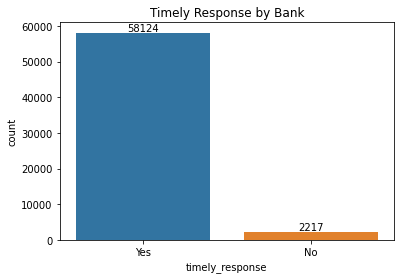

In [36]:
ax = sns.countplot(x = 'timely_response',data = df)
ax.bar_label(ax.containers[0])
plt.title('Timely Response by Bank')
plt.show()

This shows that the company has by far solved the issues of consumers timely. 

In [37]:
sv = df.groupby('submitted_via').agg({'submitted_via': 'count'})
sv

,submitted_via
submitted_via,
Email,2
Fax,231
Phone,4492
Postal mail,1286
Referral,10604
Web,43644
Web Referral,82


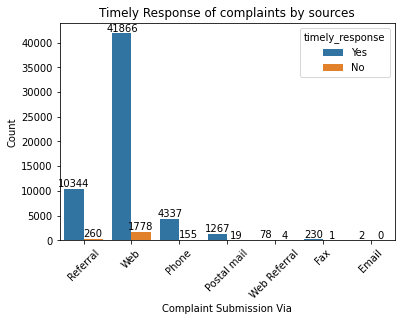

In [38]:
ax = sns.countplot(x = 'submitted_via', data = df, hue = 'timely_response')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Timely Response of complaints by sources")
plt.xlabel('Complaint Submission Via')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

From this plot, we can see that most of the complaints that receive a timely response are being lodged through web. Referral is
the second best option that provides timely response after lodging a complaint through it. 

In [39]:
df['date_diff'].value_counts()

0      47727
1       5474
2       1570
3       1248
4        814
       ...  
90         1
76         1
275        1
63         1
67         1
Name: date_diff, Length: 102, dtype: int64

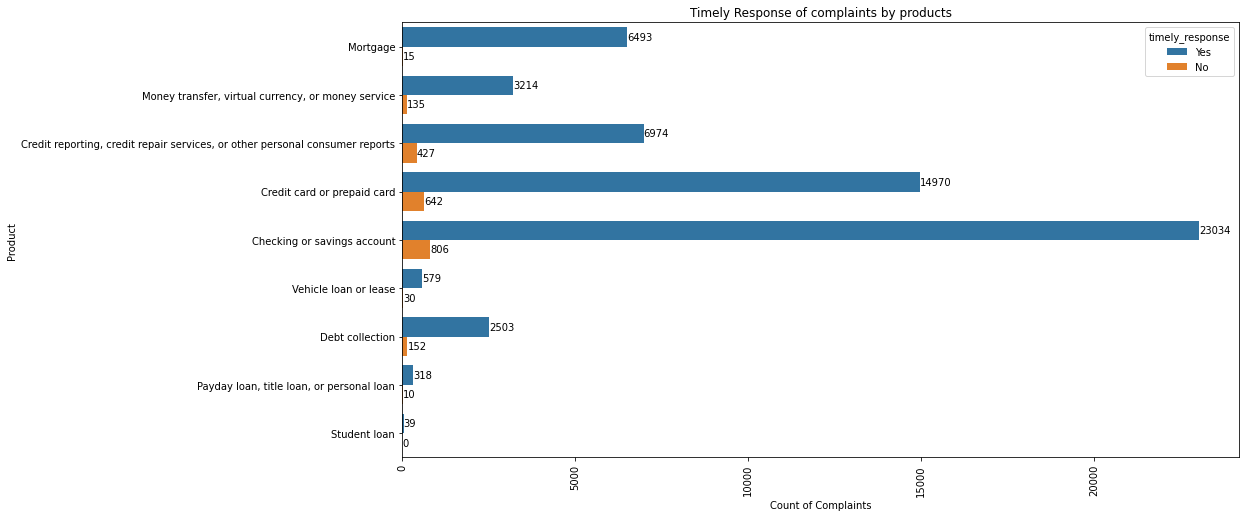

In [40]:
plt.figure(figsize = (15,8))
ax = sns.countplot(y = 'product', data = df, hue = 'timely_response',)
for label in ax.containers:
    ax.bar_label(label)
plt.title("Timely Response of complaints by products")
plt.xlabel('Count of Complaints')
plt.ylabel('Product')
plt.xticks(rotation = 90)
plt.show()

The products with most number of complaints are checking or savings account and credit card or prepaid card. The products with 
the lowest complaints are student loan, debt collection and payday loan, title loan or personal loan.

In [41]:
df.to_csv('Consumer_Complaints.csv', index = False)